In [6]:
import osmnx as ox

north = 26.98
south = 26.80
east = 75.90
west = 75.65

G = ox.graph_from_bbox(
    (west, south, east, north),
    network_type="drive"
)

print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))

Nodes: 79355
Edges: 208272


In [1]:
from sklearn.neighbors import BallTree

print("BallTree:", BallTree)

BallTree: <class 'sklearn.neighbors._ball_tree.BallTree'>


In [2]:
ox.save_graphml(
    G,
    filepath="../datasets/jaipur_osm/jaipur_graph.graphml"
)

print("Graph saved successfully!")

Graph saved successfully!


In [2]:
import osmnx as ox

print("OSMnx:", ox.__version__)
print("BallTree available:", ox.distance.BallTree)

OSMnx: 2.1.1
BallTree available: <class 'sklearn.neighbors._ball_tree.BallTree'>


In [3]:
import sklearn
from sklearn.neighbors import BallTree

print(sklearn.__version__)
print(BallTree)

1.9.1
<class 'sklearn.neighbors._ball_tree.BallTree'>


In [4]:
import osmnx as ox
from sklearn.neighbors import BallTree

ox.distance.BallTree = BallTree

print("OSMnx BallTree:", ox.distance.BallTree)

OSMnx BallTree: <class 'sklearn.neighbors._ball_tree.BallTree'>


In [3]:
import osmnx as ox

nodes, edges = ox.graph_to_gdfs(G)

nodes.to_csv("../datasets/jaipur_osm/nodes.csv")
edges.to_csv("../datasets/jaipur_osm/edges.csv")

print("Nodes saved:", len(nodes))
print("Edges saved:", len(edges))

Nodes saved: 79355
Edges saved: 208272


In [4]:
print("Node columns:")
print(nodes.columns.tolist())

print("\nEdge columns:")
print(edges.columns.tolist())

Node columns:
['y', 'x', 'street_count', 'highway', 'junction', 'geometry']

Edge columns:
['osmid', 'highway', 'lanes', 'oneway', 'ref', 'reversed', 'length', 'name', 'geometry', 'tunnel', 'junction', 'maxspeed', 'access', 'bridge', 'width']


In [5]:
print("Total edges:", len(edges))

print("Edges with maxspeed:")
print(edges["maxspeed"].notna().sum())

print("Edges without maxspeed:")
print(edges["maxspeed"].isna().sum())

Total edges: 208272
Edges with maxspeed:
3130
Edges without maxspeed:
205142


In [6]:
print(edges["highway"].value_counts().head(15))

highway
residential                     186259
tertiary                         16735
secondary                         1747
primary                           1309
trunk                              767
living_street                      504
tertiary_link                      461
primary_link                       140
unclassified                       114
secondary_link                      83
trunk_link                          71
[residential, living_street]        60
motorway_link                        5
[residential, tertiary]              4
[residential, unclassified]          2
Name: count, dtype: int64


In [7]:
print(edges["maxspeed"].value_counts().head(30))

maxspeed
40          1528
30           594
60           413
50           393
20            74
80            51
70            34
25            26
100            9
[40, 50]       3
[40, 30]       2
35             2
[80, 60]       1
Name: count, dtype: int64


In [10]:
edges_temp = edges.copy()

# Clean highway
edges_temp["highway_clean"] = edges_temp["highway"].apply(
    lambda x: ", ".join(map(str, x)) if isinstance(x, list) else str(x)
)

# Clean maxspeed
edges_temp["maxspeed_clean"] = edges_temp["maxspeed"].apply(
    lambda x: ", ".join(map(str, x)) if isinstance(x, list) else str(x)
)

# Remove missing maxspeed
speed_data = edges_temp[
    edges_temp["maxspeed"].notna()
]

# Count speed values for each road type
speed_by_road = (
    speed_data
    .groupby(["highway_clean", "maxspeed_clean"])
    .size()
    .sort_values(ascending=False)
)

print(speed_by_road)

highway_clean              maxspeed_clean
tertiary                   40                1005
residential                30                 440
                           40                 399
tertiary                   50                 221
                           30                 133
secondary                  60                 130
tertiary                   60                 100
secondary                  40                  90
primary                    60                  88
residential                60                  85
secondary                  50                  52
residential                50                  46
                           20                  44
primary                    50                  42
trunk                      80                  36
primary                    70                  34
trunk                      50                  32
tertiary                   20                  29
residential                25                  26
secondar

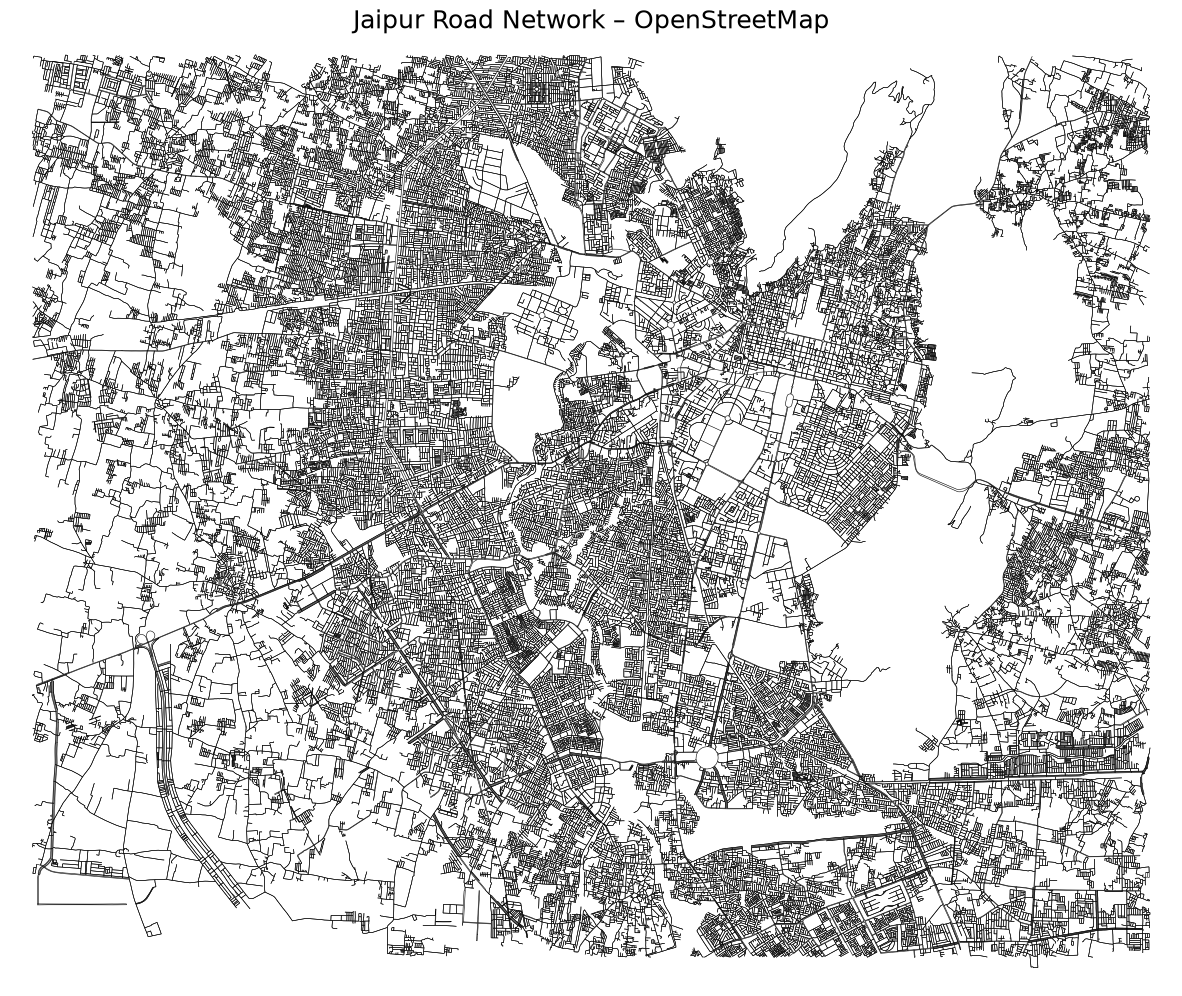

In [12]:
import osmnx as ox
import matplotlib.pyplot as plt

# Plot Jaipur road network
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color="black",
    edge_linewidth=0.4,
    bgcolor="white",
    figsize=(15, 15),
    show=False,
    close=False
)

ax.set_title("Jaipur Road Network – OpenStreetMap", fontsize=18)

# Save high-quality image
plt.savefig(
    "../outputs/jaipur_road_network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
import pandas as pd
import numpy as np

# Load original edges
edges = pd.read_csv("../datasets/jaipur_osm/edges.csv")

print("Total edges:", len(edges))
print(edges[["highway", "maxspeed", "length"]].head())

Total edges: 208272
       highway maxspeed      length
0        trunk      NaN   45.839248
1        trunk      NaN   52.388704
2        trunk      NaN   89.357876
3  residential      NaN  120.955162
4   trunk_link      NaN   83.080847


C:\Users\Mohit sharma\AppData\Local\Temp\ipykernel_5064\1417732302.py:5: DtypeWarning: Columns (5: lanes, 14: maxspeed, 17: width) have mixed types. Specify dtype option on import or set low_memory=False.
  edges = pd.read_csv("../datasets/jaipur_osm/edges.csv")


In [14]:
# Default speeds (km/h) for roads where OSM maxspeed is missing
default_speeds = {
    "motorway": 100,
    "trunk": 80,
    "primary": 60,
    "secondary": 50,
    "tertiary": 40,
    "residential": 30,
    "living_street": 20,
    "unclassified": 30,
    "service": 20
}


def parse_speed(value):
    """
    Convert OSM maxspeed value into a numeric km/h value.
    """
    if pd.isna(value):
        return np.nan

    # Handle list-like values such as ['40', '50']
    if isinstance(value, list):
        values = []
        for v in value:
            try:
                values.append(float(str(v).replace(" km/h", "").strip()))
            except:
                pass

        if values:
            return np.mean(values)

        return np.nan

    # Handle strings
    value = str(value).strip()

    # Remove common units
    value = value.replace(" km/h", "").replace("kph", "").strip()

    # Handle values such as "[40, 50]"
    if value.startswith("[") and value.endswith("]"):
        value = value[1:-1]
        parts = value.split(",")

        values = []

        for part in parts:
            try:
                values.append(float(part.strip().replace("'", "")))
            except:
                pass

        if values:
            return np.mean(values)

        return np.nan

    try:
        return float(value)
    except:
        return np.nan


# Convert OSM maxspeed into numeric values
edges["speed_kmh"] = edges["maxspeed"].apply(parse_speed)


# Function to get road type
def get_road_type(value):
    if isinstance(value, list):
        return str(value[0])
    return str(value)


edges["road_type"] = edges["highway"].apply(get_road_type)


# Fill missing speeds using road-type defaults
edges["speed_kmh"] = edges.apply(
    lambda row: (
        row["speed_kmh"]
        if not pd.isna(row["speed_kmh"])
        else default_speeds.get(row["road_type"], 30)
    ),
    axis=1
)


print(edges[["road_type", "maxspeed", "speed_kmh"]].head(20))

      road_type maxspeed  speed_kmh
0         trunk      NaN       80.0
1         trunk      NaN       80.0
2         trunk      NaN       80.0
3   residential      NaN       30.0
4    trunk_link      NaN       30.0
5         trunk      NaN       80.0
6         trunk      NaN       80.0
7   residential      NaN       30.0
8         trunk      NaN       80.0
9         trunk      NaN       80.0
10  residential      NaN       30.0
11        trunk      NaN       80.0
12  residential      NaN       30.0
13        trunk      NaN       80.0
14        trunk      NaN       80.0
15  residential      NaN       30.0
16  residential      NaN       30.0
17        trunk      NaN       80.0
18        trunk      NaN       80.0
19        trunk      NaN       80.0


In [15]:
default_speeds = {
    "motorway": 100,
    "motorway_link": 80,
    "trunk": 80,
    "trunk_link": 60,
    "primary": 60,
    "primary_link": 50,
    "secondary": 50,
    "secondary_link": 40,
    "tertiary": 40,
    "tertiary_link": 30,
    "residential": 30,
    "living_street": 20,
    "unclassified": 30,
    "service": 20
}

In [16]:
edges["speed_kmh"] = edges["maxspeed"].apply(parse_speed)

In [17]:
print(edges[["road_type", "maxspeed", "speed_kmh"]].head(20))

      road_type maxspeed  speed_kmh
0         trunk      NaN        NaN
1         trunk      NaN        NaN
2         trunk      NaN        NaN
3   residential      NaN        NaN
4    trunk_link      NaN        NaN
5         trunk      NaN        NaN
6         trunk      NaN        NaN
7   residential      NaN        NaN
8         trunk      NaN        NaN
9         trunk      NaN        NaN
10  residential      NaN        NaN
11        trunk      NaN        NaN
12  residential      NaN        NaN
13        trunk      NaN        NaN
14        trunk      NaN        NaN
15  residential      NaN        NaN
16  residential      NaN        NaN
17        trunk      NaN        NaN
18        trunk      NaN        NaN
19        trunk      NaN        NaN


In [18]:
print("Total edges:", len(edges))
print("Missing speeds:", edges["speed_kmh"].isna().sum())

print("\nSpeed distribution:")
print(edges["speed_kmh"].value_counts().sort_index())

Total edges: 208272
Missing speeds: 205142

Speed distribution:
speed_kmh
20.0       74
25.0       26
30.0      594
35.0        4
40.0     1528
45.0        3
50.0      393
60.0      413
70.0       35
80.0       51
100.0       9
Name: count, dtype: int64


In [19]:
# Step 2.1 — Assign baseline speeds

default_speeds = {
    "motorway": 100,
    "motorway_link": 80,
    "trunk": 80,
    "trunk_link": 60,
    "primary": 60,
    "primary_link": 50,
    "secondary": 50,
    "secondary_link": 40,
    "tertiary": 40,
    "tertiary_link": 30,
    "residential": 30,
    "living_street": 20,
    "unclassified": 30,
    "service": 20
}


# Convert OSM maxspeed to numeric
edges["speed_kmh"] = edges["maxspeed"].apply(parse_speed)


# Get primary road type
def get_road_type(value):
    if isinstance(value, list):
        return str(value[0])
    return str(value)


edges["road_type"] = edges["highway"].apply(get_road_type)


# Fill missing speeds using road-type defaults
edges["speed_kmh"] = edges["speed_kmh"].fillna(
    edges["road_type"].map(default_speeds)
)

# Any road types not in our dictionary get 30 km/h
edges["speed_kmh"] = edges["speed_kmh"].fillna(30)


# Check result
print("Total edges:", len(edges))
print("Missing speeds:", edges["speed_kmh"].isna().sum())

print("\nSample:")
print(edges[["road_type", "maxspeed", "speed_kmh"]].head(20))

print("\nSpeed distribution:")
print(edges["speed_kmh"].value_counts().sort_index())

Total edges: 208272
Missing speeds: 0

Sample:
      road_type maxspeed  speed_kmh
0         trunk      NaN       80.0
1         trunk      NaN       80.0
2         trunk      NaN       80.0
3   residential      NaN       30.0
4    trunk_link      NaN       60.0
5         trunk      NaN       80.0
6         trunk      NaN       80.0
7   residential      NaN       30.0
8         trunk      NaN       80.0
9         trunk      NaN       80.0
10  residential      NaN       30.0
11        trunk      NaN       80.0
12  residential      NaN       30.0
13        trunk      NaN       80.0
14        trunk      NaN       80.0
15  residential      NaN       30.0
16  residential      NaN       30.0
17        trunk      NaN       80.0
18        trunk      NaN       80.0
19        trunk      NaN       80.0

Speed distribution:
speed_kmh
20.0        564
25.0         26
30.0     186457
35.0          4
40.0      16838
45.0          3
50.0       1987
60.0       1607
70.0         35
80.0        742
100.0 

In [20]:
# Step 2.2 — Calculate travel time

edges["travel_time_seconds"] = (
    edges["length"] / (edges["speed_kmh"] / 3.6)
)

print(edges[
    ["road_type", "length", "speed_kmh", "travel_time_seconds"]
].head(20))


      road_type      length  speed_kmh  travel_time_seconds
0         trunk   45.839248       80.0             2.062766
1         trunk   52.388704       80.0             2.357492
2         trunk   89.357876       80.0             4.021104
3   residential  120.955162       30.0            14.514619
4    trunk_link   83.080847       60.0             4.984851
5         trunk  482.195683       80.0            21.698806
6         trunk   17.672923       80.0             0.795282
7   residential   49.997449       30.0             5.999694
8         trunk   81.091652       80.0             3.649124
9         trunk    9.823587       80.0             0.442061
10  residential   32.807292       30.0             3.936875
11        trunk  203.762042       80.0             9.169292
12  residential   64.242820       30.0             7.709138
13        trunk   49.860747       80.0             2.243734
14        trunk   97.488846       80.0             4.386998
15  residential   71.086569       30.0  

In [21]:
print(edges["travel_time_seconds"].describe())

count    208272.000000
mean          7.791231
std           7.580324
min           0.061004
25%           3.888682
50%           5.788196
75%           9.636145
max         641.328162
Name: travel_time_seconds, dtype: float64


In [22]:
print("\nMinimum travel time:",
      edges["travel_time_seconds"].min(), "seconds")

print("Maximum travel time:",
      edges["travel_time_seconds"].max(), "seconds")

print("Mean travel time:",
      edges["travel_time_seconds"].mean(), "seconds")


Minimum travel time: 0.061004417649440736 seconds
Maximum travel time: 641.3281623862521 seconds
Mean travel time: 7.791231214014439 seconds


In [23]:
# Save processed baseline road data

baseline_edges = edges[
    [
        "u",
        "v",
        "key",
        "road_type",
        "length",
        "speed_kmh",
        "travel_time_seconds"
    ]
].copy()

baseline_edges.to_csv(
    "../datasets/jaipur_osm/edges_baseline.csv",
    index=False
)

print("Saved successfully!")
print("Rows:", len(baseline_edges))
print("File: datasets/jaipur_osm/edges_baseline.csv")


Saved successfully!
Rows: 208272
File: datasets/jaipur_osm/edges_baseline.csv


In [24]:
import osmnx as ox
import networkx as nx

# Load Jaipur road graph
G = ox.load_graphml(
    "../datasets/jaipur_osm/jaipur_graph.graphml"
)

print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))    

Nodes: 79355
Edges: 208272


In [7]:
# Jaipur Railway Station
source_lat = 26.9196
source_lon = 75.7878

# Hawa Mahal
dest_lat = 26.9239
dest_lon = 75.8267

source_node = ox.distance.nearest_nodes(
    G,
    X=source_lon,
    Y=source_lat
)

dest_node = ox.distance.nearest_nodes(
    G,
    X=dest_lon,
    Y=dest_lat
)

print("Source node:", source_node)
print("Destination node:", dest_node)

Source node: 5491109711
Destination node: 1812532435


In [28]:
import sklearn

print("scikit-learn version:", sklearn.__version__)
print("scikit-learn location:", sklearn.__file__)



scikit-learn version: 1.9.1
scikit-learn location: c:\Users\Mohit sharma\Desktop\7th sem\new major project\geopulse\.venv\Lib\site-packages\sklearn\__init__.py


In [29]:
import osmnx as ox

print("OSMnx version:", ox.__version__)
print("BallTree available:", ox.distance.BallTree)

OSMnx version: 2.1.1
BallTree available: None


In [32]:
!pip install scikit-learn

In [9]:
# Load baseline edge weights
import pandas as pd
baseline_edges = pd.read_csv(
    "../datasets/jaipur_osm/edges_baseline.csv"
)

print(baseline_edges.head())
print("Edges:", len(baseline_edges))

           u            v  key    road_type      length  speed_kmh  \
0  245753419  11209773784    0        trunk   45.839248       80.0   
1  315733696  14045294517    0        trunk   52.388704       80.0   
2  315733696  10129981494    0        trunk   89.357876       80.0   
3  315733696    317399857    0  residential  120.955162       30.0   
4  315733698   6728974119    0   trunk_link   83.080847       60.0   

   travel_time_seconds  
0             2.062766  
1             2.357492  
2             4.021104  
3            14.514619  
4             4.984851  
Edges: 208272


In [10]:
# Add travel time to the graph

for _, row in baseline_edges.iterrows():
    u = int(row["u"])
    v = int(row["v"])
    key = int(row["key"])

    if G.has_edge(u, v, key):
        G[u][v][key]["travel_time"] = row["travel_time_seconds"]

print("Travel time added to graph.")

Travel time added to graph.


In [12]:
import networkx as nx
route = nx.shortest_path(
    G,
    source=source_node,
    target=dest_node,
    weight="travel_time"
)

print("Number of nodes in route:", len(route))

Number of nodes in route: 46


In [13]:
# Calculate total baseline travel time

total_time = 0

for u, v in zip(route[:-1], route[1:]):
    edge_data = G.get_edge_data(u, v)

    # Choose the edge with minimum travel time
    best_edge = min(
        edge_data.values(),
        key=lambda x: x["travel_time"]
    )

    total_time += best_edge["travel_time"]

print("Route nodes:", len(route))
print("Total travel time:", total_time, "seconds")
print("Total travel time:", total_time / 60, "minutes")

Route nodes: 46
Total travel time: 322.45457597610726 seconds
Total travel time: 5.374242932935121 minutes


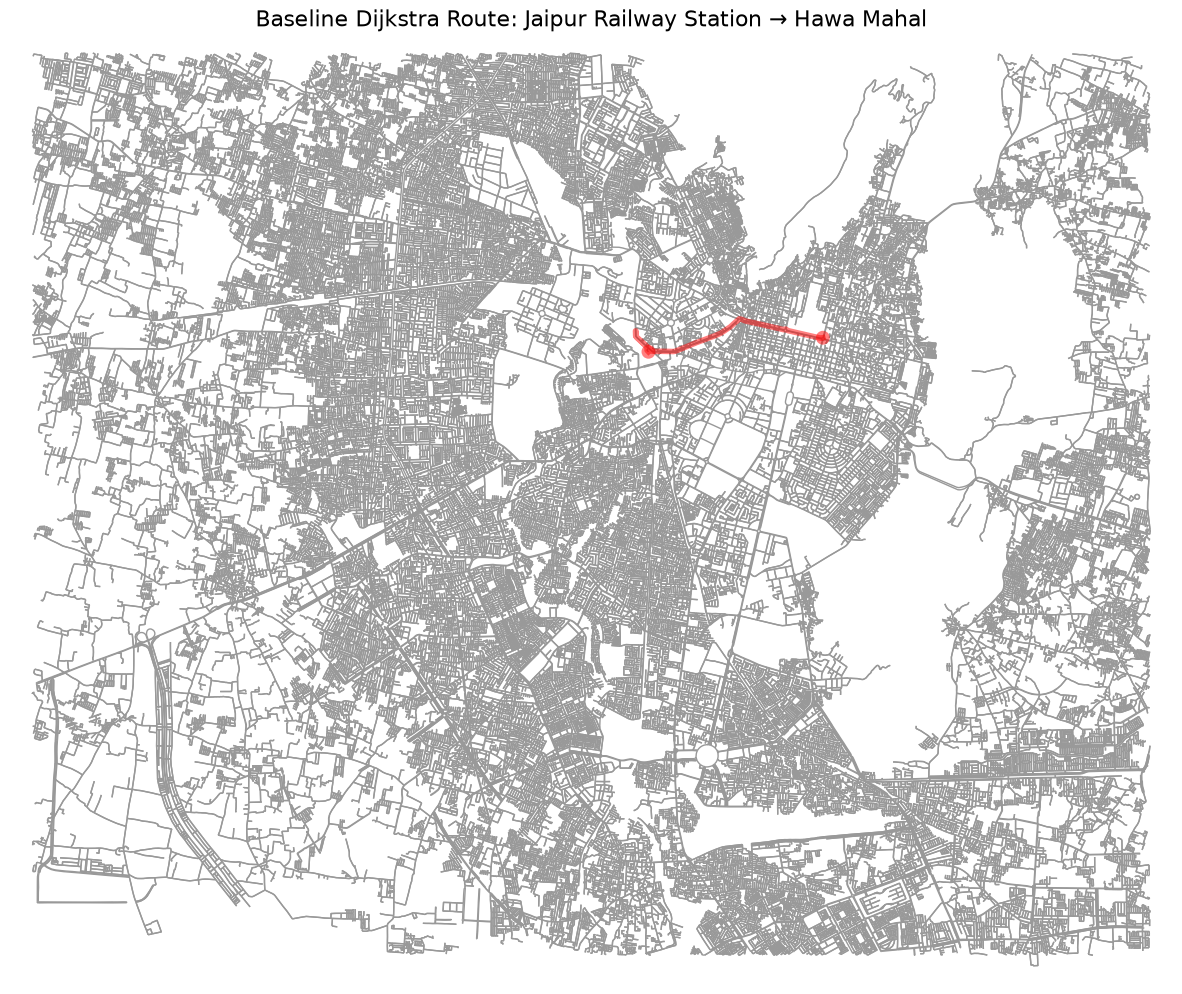

In [14]:
import matplotlib.pyplot as plt
import osmnx as ox

fig, ax = ox.plot_graph_route(
    G,
    route,
    route_linewidth=4,
    node_size=0,
    bgcolor="white",
    figsize=(15, 15),
    show=False,
    close=False
)

ax.set_title(
    "Baseline Dijkstra Route: Jaipur Railway Station → Hawa Mahal",
    fontsize=16
)

plt.savefig(
    "../outputs/baseline_dijkstra_route.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


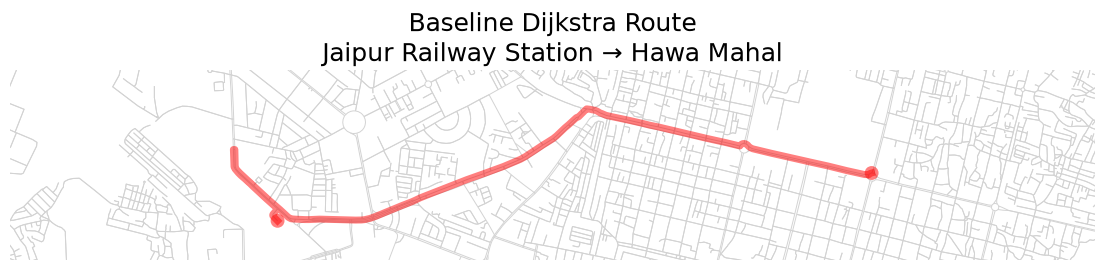

In [15]:
import matplotlib.pyplot as plt
import osmnx as ox

# Get coordinates of route nodes
route_x = [G.nodes[node]["x"] for node in route]
route_y = [G.nodes[node]["y"] for node in route]

# Calculate route bounding box
min_x, max_x = min(route_x), max(route_x)
min_y, max_y = min(route_y), max(route_y)

# Add padding around the route
padding_x = (max_x - min_x) * 0.35
padding_y = (max_y - min_y) * 0.35

fig, ax = ox.plot_graph_route(
    G,
    route,
    route_linewidth=5,
    route_color="red",
    node_size=0,
    edge_color="lightgray",
    edge_linewidth=0.7,
    bgcolor="white",
    figsize=(14, 12),
    show=False,
    close=False
)

# Zoom into route area
ax.set_xlim(min_x - padding_x, max_x + padding_x)
ax.set_ylim(min_y - padding_y, max_y + padding_y)

ax.set_title(
    "Baseline Dijkstra Route\nJaipur Railway Station → Hawa Mahal",
    fontsize=18
)

plt.savefig(
    "../outputs/baseline_dijkstra_route_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()